# Scaling study

In [1]:
import sys; sys.path.insert(0, "..")
%load_ext autoreload
%autoreload 2

from functools import partial

from algorithms.CMIICAdapter import CMIICAdapter
from algorithms.CPCAdapter import CPCAdapter
from algorithms.NOTEARSAdapter import NOTEARSAdapter
from algorithms.LiNGAMAdapter import LiNGAMAdapter
from algorithms.MIICAdapter import MIICAdapter
from algorithms.GHCBDeuAdapter import GHCBDeuAdapter

from data.generators import generate_from_sem, generate_from_cbn_dag
from scaling.runner import ScalingRunner
from scaling.plot import plot_facet, METRIC_NAMES
from scaling.io import load_results

## Configuration

In [2]:
algo_configs = [
    ("CPC",      CPCAdapter,     {"version": 1, "alpha": 0.05, "max_conditioning_set_size": 4}),
    ("CMIIC",    CMIICAdapter,   {"version": 1, "alpha": 0.01}),
    ("MIIC",     MIICAdapter,    {"n_bins": 4, "discretization_method": "quantile"}),
    ("GHC+BDeu", GHCBDeuAdapter, {"n_bins": 4, "discretization_method": "quantile"}),
    ("NOTEARS",  NOTEARSAdapter, {"lambda1": 0.01, "w_threshold_notears": 0.3}),
    ("LiNGAM",   LiNGAMAdapter,  {"threshold_lingam": 0.075}),
]

generator = partial(generate_from_sem, noise_type="laplace")
# generator = partial(generate_from_cbn_dag, marginal_type="Uniform", lcc_types="NormalCopula")

runner = ScalingRunner(
    algo_configs=algo_configs,
    generator=generator,
    generator_name="SEM_laplace",
    n_vars_list=[5, 10],
    n_samples_list=[200, 500, 1000, 2000, 5000],
    density=1.5,
    n_graphs=2,
    seed=42,
)

## Run

In [3]:
df = runner.run()

[120/120] LiNGAM | v=10 a=15 s=5000 g=111


## (ou charger des résultats existants)

In [4]:
#df = load_results("results/cbn_unif_normal/results.csv")

## Visualisation

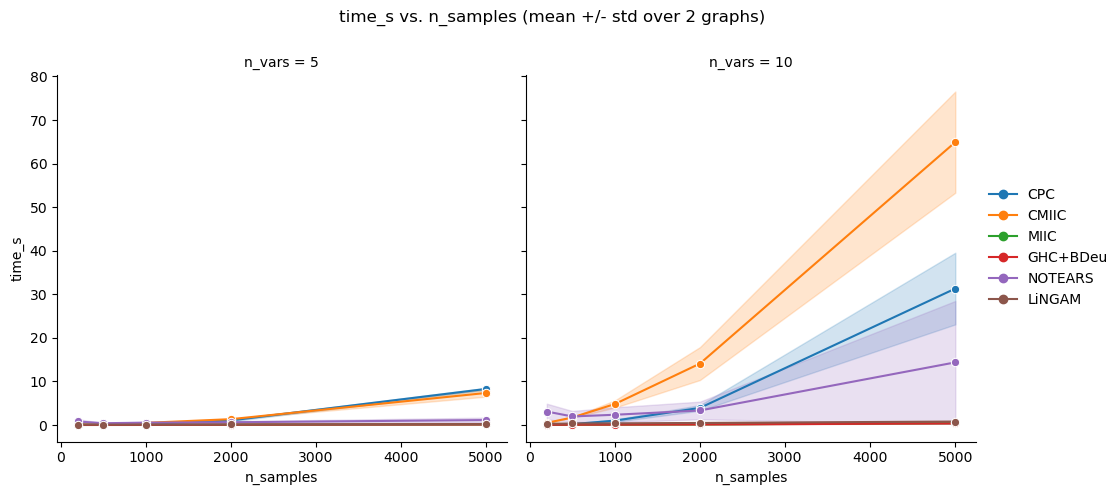

In [5]:
plot_facet(df, y="time_s", col="n_vars"); # Temps de calcul

## Métriques

### Sur les CPDAG

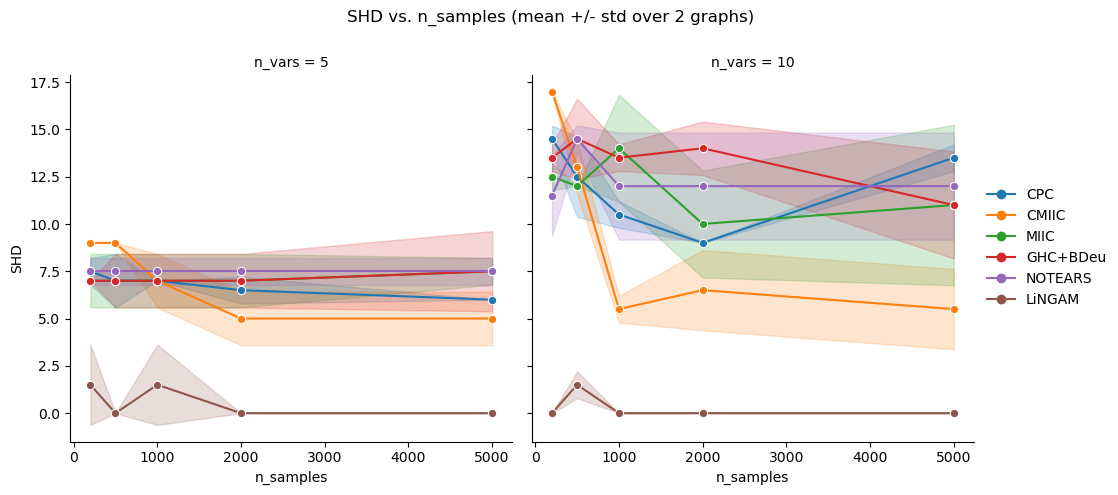

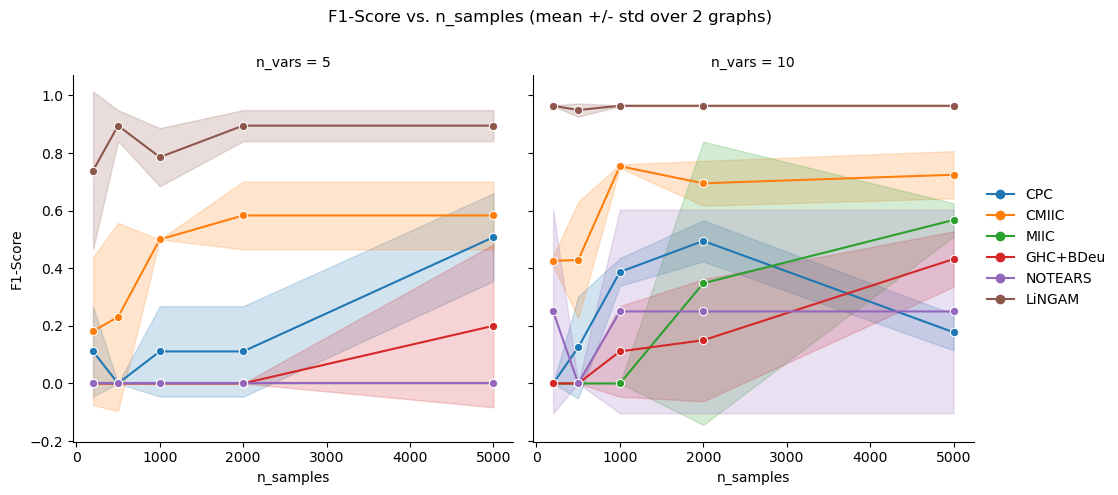

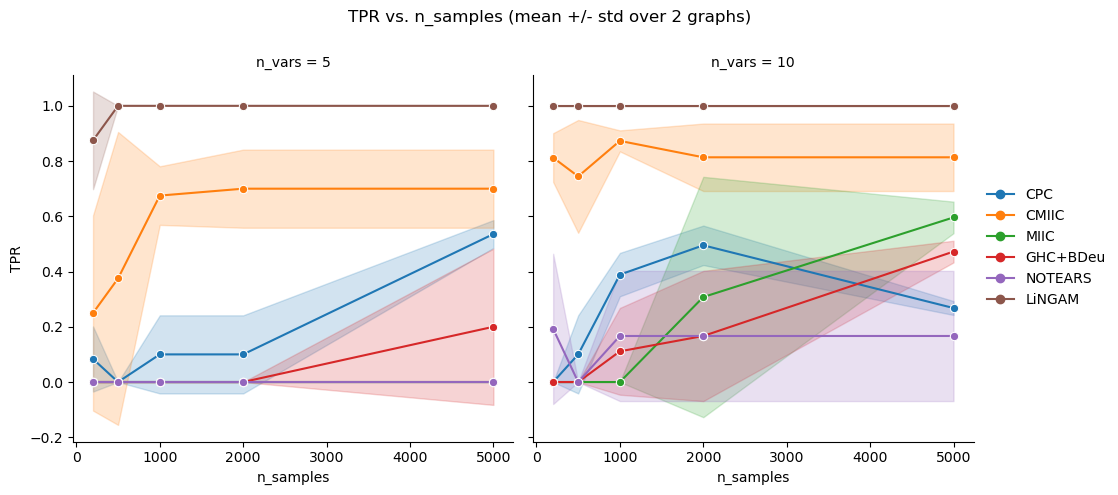

In [6]:
for metric in METRIC_NAMES:
    plot_facet(df, y=metric, col="n_vars");

### Sur les squelettes

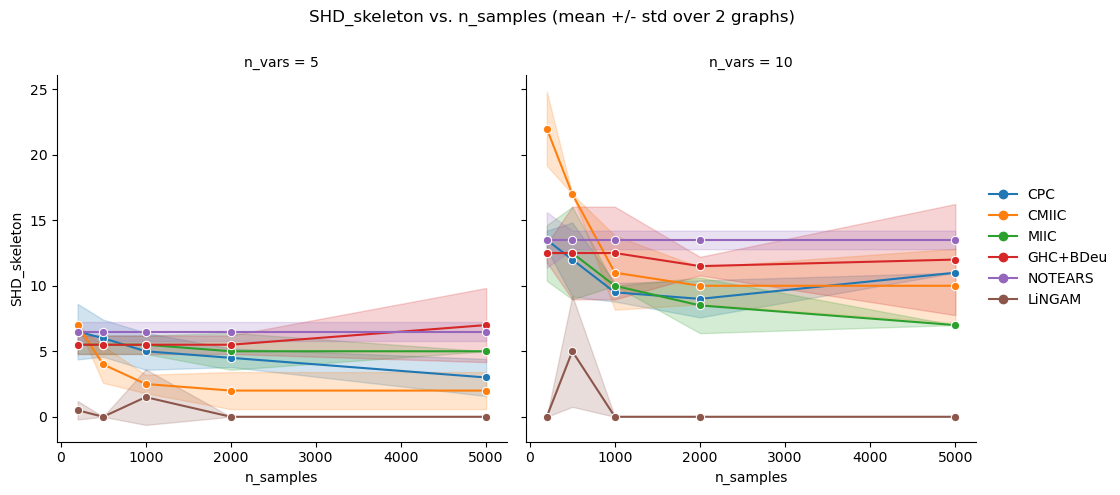

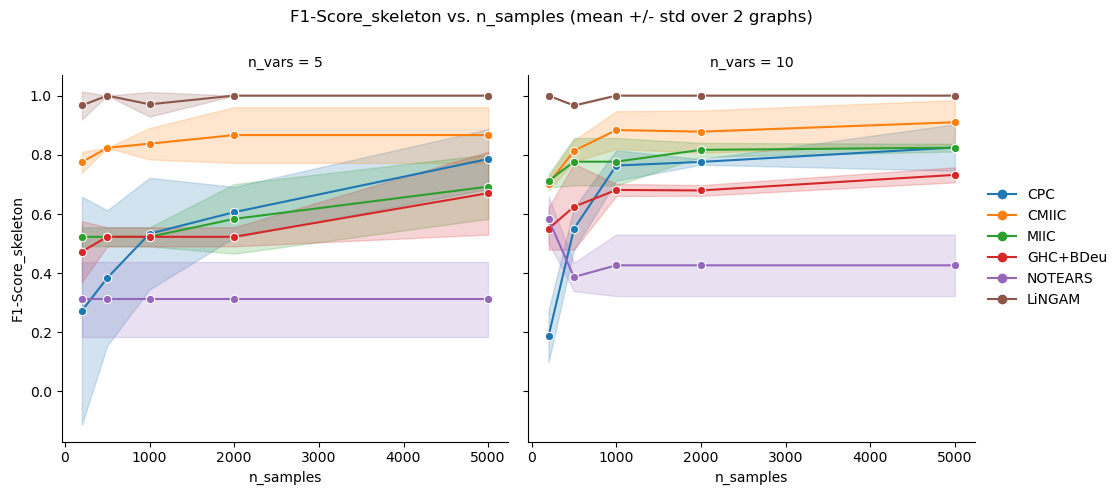

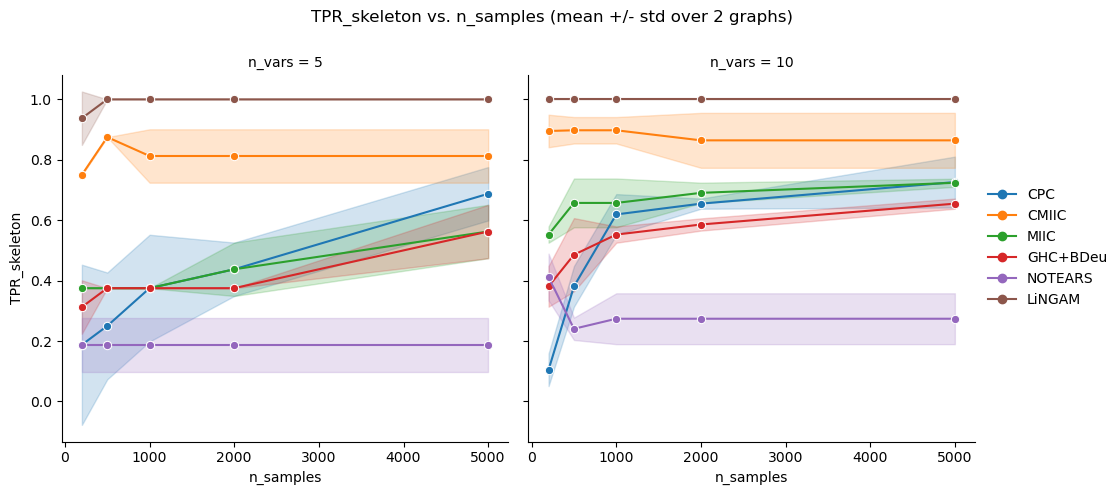

In [7]:
for metric in METRIC_NAMES:
    plot_facet(df, y=f"{metric}_skeleton", col="n_vars");